# Mask and Segment Tibia Bone
*Created by: Danielle Whittier, PhD*
Last updated: July 9 2026

This Notebook provides a basic process to segmentthe bone marrow ans epiphysis compartment of a mouse tibia scan from microCT
<br> It is assumed that the input file is a greyscle .aim of the tibia aligned axially in the z direction. 
<br> Input also assume an acompanying mask.aim file of the whole bone.
<br>
<br> Note that this is a work in progress and built based on several protocols described in the literature
<br> tuning is still required.



# Setup

In [1]:
import numpy as np
import importlib
import gc

from scipy import ndimage as ndi
from helper_functions.vtk_util import vtkImageData_to_numpy, numpy_to_vtkImageData

#ensure the helper functions are saved in your working folder
from helper_functions.aim_calibration_header import get_aim_density_equation, get_aim_calibration_constants_from_processing_log
import helper_functions.read_write_aim_files as aim_io
import helper_functions.marrow_mask_generation as morph
import helper_functions.viewer as viewers


import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
#plot widget feature
%matplotlib widget

# set the working directory to where the Jupyter notebook is currently located
%pwd  
%cd . 

/Users/daniellewhittier/Library/CloudStorage/OneDrive-UniversityofCalgary/Research/mouse_bmat


# Step 1: Read in image and bone mask
Define files to read. You should only need to change the root name if file path and naming convention stay the same

In [3]:
root_name = "AS_PRX1_5F4_LT"

raw_dir = Path("outputs")
processed_dir = Path("processed_image_data")
output_dir = Path("outputs")

output_dir.mkdir(exist_ok=True)

# Inputs
img_file = raw_dir / f"{root_name}.aim"
mask_file = raw_dir / f"{root_name}_MASK.aim"

# Primary Outputs
seg_bone_file = output_dir / f"{root_name}_SEG.AIM" #contains segmented bone with cort, trab, and epiphysis labelled
marrow_mask_file = output_dir / f"{root_name}_MARROW_MASKS.AIM" #contains compartment masks (main and epiphysis) labelled 
subregion_mask_file = output_dir / f"{root_name}_SUB_ROI_MASKS.AIM" #contains distal and proximal sub region masks labelled 

#### Read in files and prep
- Greyscale image is converted to BMD
- Whole bone mask and greyscale image are aligned based on global positioning

In [4]:
img_data = aim_io.read_aim_with_position(img_file, scaling="BMD")
mask_data = aim_io.read_aim_with_position(mask_file, scaling="binary")

np_img_bone = img_data["array"]          # BMD image

np_bone_mask, mask_offset = aim_io.paste_mask_into_image_grid(mask_array=mask_data["array"],image_shape=img_data["array"].shape,
    mask_position=mask_data["position"],image_position=img_data["position"],binarize=True)

outputs/AS_PRX1_5F4_LT.aim
  dimensions [voxels]: [ 643  648 1829]
  spacing [mm]:        [0.01 0.01 0.01]
  global position:     [296 275   0]
  numpy shape:         (643, 648, 1829)

image converted to bone mineral density
outputs/AS_PRX1_5F4_LT_MASK.aim
  dimensions [voxels]: [ 640  644 1827]
  spacing [mm]:        [0.01 0.01 0.01]
  global position:     [297 277   1]
  numpy shape:         (640, 644, 1827)

image assumed to be binary, values are unchanged
Image position: [296 275   0]
Mask position:  [297 277   1]
Mask offset in image grid: [1 2 1]
Source crop start: [0 0 0]
Source crop end:   [ 640  644 1827]
Dest paste start:  [1 2 1]
Dest paste end:    [ 641  646 1828]


#### Quick visualization of whole bone mask
Use if needed

In [5]:
viewer = viewers.qc_masks(np_img_bone,
    masks={
        "Whole bone": np_bone_mask,
    },
    colors={
        "Whole bone": "yellow",
    },
    ds=2,
    alpha=0.4,
    title="Compartment QC"
)

# Step 2: Segment marrow compartments

#### Specify input parameters for generating compartment masks

In [6]:
bone_threshold_bmd = 200  # default is 200. this is lower threshold than used for true seg bone and intended only for generating masks
gaussian_sigma_vox = 1.0  # default is 1.0. Smoothing sigma in voxels
bone_closing_radius_vox = 3   # default is 3. Dilation/erosion radius in voxels for filling gaps in bone segmentation

compartment_radius_vox = 10   # default is 10. Dilation/erosion radius in voxels for filling bone marrow to capture trabeculae 
crop_pad_vox = 30

#### Generate a crude segmentation of the bone, then extract the segmentent marrow compartments

In [7]:
# Whole-bone mask as boolean
whole_bone = np_bone_mask > 0

# Smooth and threshold directly
seg_bone = (ndi.gaussian_filter(np_img_bone.astype(np.float32, copy=False),
                                sigma=gaussian_sigma_vox) >= bone_threshold_bmd)

# Restrict to whole-bone mask
seg_bone &= whole_bone

In [8]:
#extract marrow compartments (exlcudes bone)
marrow_seg, marrow_info = morph.extract_marrow_from_bone(
    seg_bone=seg_bone,
    whole_bone=whole_bone,
    connectivity=1,
    bone_closing_radius_vox=3,
    whole_bone_inner_margin_vox=1,
    use_distance_transform=False,
)

Unique marrow labels: [0, 1, 2]
Main marrow voxels: 9056788
Epiphysis marrow voxels: 725144
Component volumes [vox]: [9056788, 725144, 282134, 31744, 13441, 11283, 11205, 7400, 3735, 2946]


In [9]:
#memory cleanup step
del seg_bone
del np_bone_mask
del mask_data
gc.collect()

39

#### Visualizer to check marrow compartment is extracted properly

In [10]:
viewer = viewers.qc_masks(np_img_bone,
    masks={
       # "Segmented bone": seg_bone,
        "Main marrow": marrow_seg==1,
        "Epiphysis marrow": marrow_seg==2,
    },
    colors={
       # "Segmented bone": "yellow",
        "Main marrow": "red",
        "Epiphysis marrow": "cyan",
    },
    ds=2,
    alpha=0.35,
    title="Marrow extraction QC",
)

#### Extract main compartment and epiphysis masks

In [11]:
main_comp_outputs = morph.connectivity_aware_closing_fast_cropped(
    input_mask=(marrow_seg==1),
    search_mask=whole_bone,
    radius_vox=compartment_radius_vox,
    connectivity=1,
    crop_pad_vox=crop_pad_vox,             
    return_intermediates=False,
)

epiphysis_comp_outputs = morph.connectivity_aware_closing_fast_cropped(
    input_mask=(marrow_seg==2),
    search_mask=whole_bone,
    radius_vox=compartment_radius_vox,
    connectivity=1,
    crop_pad_vox=crop_pad_vox,              # try 3–4x radius
    return_intermediates=False,
)

Full shape: (643, 648, 1829)
Crop start: [224 122  63]
Crop end:   [ 533  463 1789]
Crop shape: [ 309  341 1726]
Full shape: (643, 648, 1829)
Crop start: [188 157   0]
Crop end:   [503 502 159]
Crop shape: [315 345 159]


In [12]:
marrow_masks = morph.combine_masks_with_labels(
    masks=[
        main_comp_outputs["output_mask"],
        epiphysis_comp_outputs["output_mask"]
    ],
    labels=[
        1,  # main compartment
        2,  # epiphysis compartment
    ],
)

#### Visualizer to check segmentation worked

In [13]:
viewer = viewers.qc_masks(np_img_bone,
    masks={
        "Main compartment": marrow_masks==1,
        "Epiphysis compartment": marrow_masks==2,
    },
    colors={
        "Main compartment": "orange",
        "Epiphysis compartment": "lime",
    },
    ds=2,
    alpha=0.45,
    title="Main and epiphysis compartments",
)

#### Write out masks and bone segmentation

In [18]:
#write marrow compartment masks
aim_io.write_mask_to_aim(mask_array = marrow_masks, output_aim_path=marrow_mask_file,reference_aim_path = img_file, foreground_value=1)

#write segmented bone
#aim_io.write_mask_to_aim(mask_array = bone_labels, output_aim_path=seg_bone_file,reference_aim_path = img_file, preserve_labels=True)

Unique values being written: [0 1 2]

Wrote: outputs/AS_PRX1_5F4_LT_MARROW_MASKS.AIM
  dimensions [voxels]: (643, 648, 1829)
  resolution [mm]:     (0.009999999776482582, 0.009999999776482582, 0.009999999776482582)
  vtk origin:          (2.9649999337270856, 2.7549999384209514, 0.004999999888241291)
  AIM position:        (296, 275, 0)
  numpy shape:         (643, 648, 1829)
  unique values:       [0 1 2]



In [14]:
#memory cleanup step
del main_comp_outputs
del epiphysis_comp_outputs
gc.collect()

9

# Step 3: Generate sub-regions for specific analysis

## Options 1: continue with scan already in use (Skip to Step 3A)
**This assumes that the following names are used:**
<br> inner_compartment = main bone marrow compartment (includes trabeculae bone and marrow)
<br> epiphysis_compartment = epiphysis bone comartment (includes trabeculae and marrow)
<br> whole_bone = full bone mask originally imported at beginning

## Option 2: Load masks and image files that were previously saved
This is suitable for when the compartment masks have been edited manually, or you've run and saved your masks in a batch and are now resuming work

In [1]:
#identical to above setup

import numpy as np
import importlib
import gc

from scipy import ndimage as ndi
from helper_functions.vtk_util import vtkImageData_to_numpy, numpy_to_vtkImageData

#ensure the helper functions are saved in your working folder
from helper_functions.aim_calibration_header import get_aim_density_equation, get_aim_calibration_constants_from_processing_log
import helper_functions.read_write_aim_files as aim_io
import helper_functions.marrow_mask_generation as morph
import helper_functions.viewer as viewers


import matplotlib.pyplot as plt

from pathlib import Path

#plot widget feature
%matplotlib widget

# set the working directory to where the Jupyter notebook is currently located
%pwd  
%cd . 

/Users/daniellewhittier/Library/CloudStorage/OneDrive-UniversityofCalgary/Research/mouse_bmat


In [2]:
# this is the same as the top of this notebook, but copied here so you can start working from this point onwards
# be sure to update the root name to the desired file 


root_name = "AS_PRX1_5F4_LT"

raw_dir = Path("raw_data")
processed_dir = Path("processed_image_data")
output_dir = Path("outputs")

output_dir.mkdir(exist_ok=True)

# Inputs
img_file = raw_dir / f"{root_name}.aim"
mask_file = raw_dir / f"{root_name}_MASK.aim"

# Primary Outputs
seg_bone_file = output_dir / f"{root_name}_SEG.AIM" #contains segmented bone with cort, trab, and epiphysis labelled
marrow_mask_file = output_dir / f"{root_name}_MARROW_MASKS.AIM" #contains compartment masks labelled 
subregion_mask_file = output_dir / f"{root_name}_SUB_ROI_MASKS.AIM" #contains distal and proximal sub region masks labelled 

In [3]:
img_data = aim_io.read_aim_with_position(img_file, scaling="BMD") # this is only used for visualizing
mask_data = aim_io.read_aim_with_position(mask_file, scaling="binary")

np_img_bone = img_data["array"]          # BMD image
whole_bone, mask_offset = aim_io.paste_mask_into_image_grid(mask_array=mask_data["array"],image_shape=img_data["array"].shape,
    mask_position=mask_data["position"],image_position=img_data["position"],binarize=True)

#whole_bone = np_bone_mask > 0

raw_data/AS_PRX1_5F4_LT.aim
  dimensions [voxels]: [ 643  648 1829]
  spacing [mm]:        [0.01 0.01 0.01]
  global position:     [296 275   0]
  numpy shape:         (643, 648, 1829)

image converted to bone mineral density
raw_data/AS_PRX1_5F4_LT_MASK.aim
  dimensions [voxels]: [ 640  644 1827]
  spacing [mm]:        [0.01 0.01 0.01]
  global position:     [297 277   1]
  numpy shape:         (640, 644, 1827)

image assumed to be binary, values are unchanged
Image position: [296 275   0]
Mask position:  [297 277   1]
Mask offset in image grid: [1 2 1]
Source crop start: [0 0 0]
Source crop end:   [ 640  644 1827]
Dest paste start:  [1 2 1]
Dest paste end:    [ 641  646 1828]


In [4]:
# read marrow masks
marrow_img = aim_io.read_aim_with_position(marrow_mask_file, scaling="binary")
marrow_masks, mask_offset = aim_io.paste_mask_into_image_grid(mask_array=marrow_img["array"],image_shape=img_data["array"].shape,
    mask_position=marrow_img["position"],image_position=img_data["position"],binarize=False)

outputs/AS_PRX1_5F4_LT_MARROW_MASKS.AIM
  dimensions [voxels]: [ 643  648 1829]
  spacing [mm]:        [0.01 0.01 0.01]
  global position:     [296 275   0]
  numpy shape:         (643, 648, 1829)

image assumed to be binary, values are unchanged
Image position: [296 275   0]
Mask position:  [296 275   0]
Mask offset in image grid: [0 0 0]
Source crop start: [0 0 0]
Source crop end:   [ 643  648 1829]
Dest paste start:  [0 0 0]
Dest paste end:    [ 643  648 1829]


## Step 3A: Get proximal sub-region that is 10% of whole bone length

In [15]:
main_compartment_top10, top10_info = morph.extract_compartment_region_by_bone_length(
    compartment_mask=marrow_masks,
    whole_bone_mask=whole_bone,
    percent_length=10,
    label_to_use=1,
    axis=2,
    start_from="min",  # switch to "max" if growth plate is at upper z on viewer
)

top10_info

{'label_to_use': 1,
 'axis': 2,
 'start_from': 'min',
 'bone_start': 11,
 'bone_end': 1812,
 'bone_length_vox': 1801,
 'percent_length': 10,
 'region_length_vox': 180,
 'compartment_start': 93,
 'compartment_end': 1759,
 'region_start': 93,
 'region_end': 273,
 'subregion_voxels': 3410216}

## Step 3B Find tib-fib junction and extract distal sub region

#### Primary Approach: Automated detection of tib-fib junction

Detected tib-fib junction z: 1078


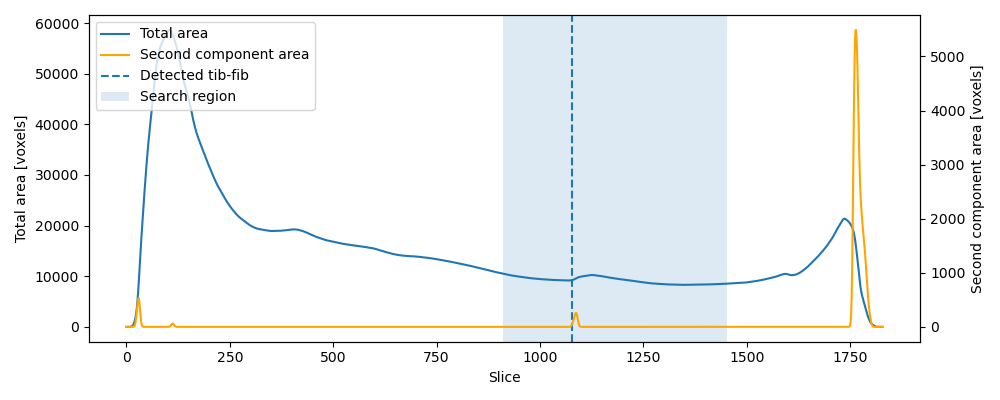

In [16]:
tibfib_z, tibfib_info = morph.detect_tibfib_junction_from_mask(
    whole_bone_mask=whole_bone,
    axis=2,
    smooth_sigma=3,
    min_second_component_area_vox=50,
    persistence_slices=5,
    search_fraction=(0.5, 0.8),
    mode="first_persistent",
)

print("Detected tib-fib junction z:", tibfib_z)

# quick plot to check where search area along bone
fig, ax1 = plt.subplots(figsize=(10, 4))

# Primary y-axis: total area
line1 = ax1.plot(tibfib_info["total_area_smooth"],label="Total area")
ax1.set_xlabel("Slice")
ax1.set_ylabel("Total area [voxels]")

# Secondary y-axis: second component area
ax2 = ax1.twinx()
line2 = ax2.plot(tibfib_info["second_area_smooth"],label="Second component area",color="orange")
ax2.set_ylabel("Second component area [voxels]")

# Junction and search region
vline = ax1.axvline(tibfib_info["junction_slice"],linestyle="--",label="Detected tib-fib")
span = ax1.axvspan(tibfib_info["search_start"],tibfib_info["search_end"],alpha=0.15,label="Search region")

# Combined legend
lines = line1 + line2 + [vline, span]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.tight_layout()
plt.show()

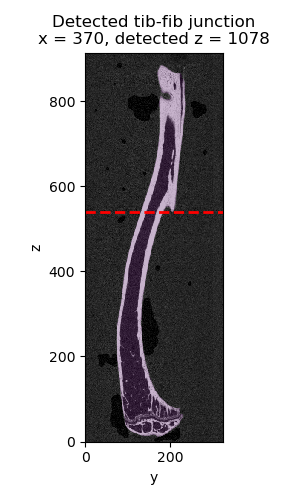

In [17]:
viewers.show_detected_slice_sagittal(
    image=np_img_bone,
    detected_slice=tibfib_z,
    mask=whole_bone,
    x=None,
    ds=2,
    title="Detected tib-fib junction",
    line_color="red",
)

#### Alternate Approach - manually select the slice for the tib-fib junction
__NOTE__: do not run this if the automatic approach worked!

In [23]:
tibfib_viewer = morph.tibfib_slice_picker(
    image=np_img_bone,
    mask=whole_bone,
    ds=2,
    title="Select tib-fib junction",
)

tibfib_z = tibfib_viewer["z_slider"].value * tibfib_viewer["ds"]
tibfib_z

682

### Extract distal sub-region
This will use the slice determined by the last run step from above (either automatic or manual)

In [18]:
main_compartment_distal_tibfib, tibfib_region_info = morph.extract_region_from_slice(
    compartment_mask=marrow_masks==1,
    start_slice=tibfib_z,
    axis=2,
    direction="distal_max",  # switch if distal is toward lower z
)

## Combine into labelled mask and save

In [19]:
subregion_masks, subregion_info = morph.label_mask_regions(
    masks={
        "top10": main_compartment_top10,
        "distal_tibfib": main_compartment_distal_tibfib,
    },
    labels={
        "top10": 3,
        "distal_tibfib": 4,
    },
    priority_order=[
        "top10",
        "distal_tibfib",
    ],
)

Unique labels: [0, 3, 4]
background: 757170797
top10 label 3: 3410216
distal_tibfib label 4: 1497443


In [20]:
#visual check of both sub ROI masks
viewers.qc_masks(
    image=np_img_bone,
    masks={
        "Top 10%": subregion_masks == 3,
        "Distal tib-fib": subregion_masks == 4,
    },
    colors={
        "Top 10%": "lime",
        "Distal tib-fib": "red",
    },
    ds=2,
    alpha=0.45,
    title="Marrow compartment subregions",
)

In [33]:
#save sub ROI mask file
aim_io.write_mask_to_aim(
    mask_array=subregion_masks,
    output_aim_path=subregion_mask_file,
    reference_aim_path=str(img_file),
    preserve_labels=True,
)

Unique values being written: [0 3 4]

Wrote: outputs/AS_PRX1_5F4_LT_SUB_ROI_MASKS.AIM
  dimensions [voxels]: (643, 648, 1829)
  resolution [mm]:     (0.009999999776482582, 0.009999999776482582, 0.009999999776482582)
  vtk origin:          (2.9649999337270856, 2.7549999384209514, 0.004999999888241291)
  AIM position:        (296, 275, 0)
  numpy shape:         (643, 648, 1829)
  unique values:       [0 3 4]



#### Generate bone segmentation with cortical, trbaecular, and epiphysis labelled

In [21]:
bone_labels = morph.segment_mineralized_bone_compartments(
    image=np_img_bone,
    whole_bone_mask=whole_bone,
    compartment_seg=marrow_masks,
    bone_threshold=300,
    gaussian_sigma_vox=0.8,
    label_cortical=5,
    label_trabecular=6,
    label_epiphysis=7,
    return_info=False,
)

In [22]:
viewer = viewers.qc_masks(np_img_bone,
    masks={
        "Cortical bone": bone_labels==5,
        "Trabecular bone": bone_labels==6,
        "Epiphysis bone": bone_labels==7,
    },
    colors={
        "Cortical bone": "orange",
        "Trabecular bone": "red",
        "Epiphysis bone": "lime",
    },
    ds=2,
    alpha=0.8,
    title="Compartment QC",
)

In [38]:
#save segmented bone to seg file
aim_io.write_mask_to_aim(
    mask_array=bone_labels,
    output_aim_path=seg_bone_file,
    reference_aim_path=img_file,
    preserve_labels=True,
)

Unique values being written: [0 5 6 7]

Wrote: outputs/AS_PRX1_5F4_LT_SEG.AIM
  dimensions [voxels]: (643, 648, 1829)
  resolution [mm]:     (0.009999999776482582, 0.009999999776482582, 0.009999999776482582)
  vtk origin:          (2.9649999337270856, 2.7549999384209514, 0.004999999888241291)
  AIM position:        (296, 275, 0)
  numpy shape:         (643, 648, 1829)
  unique values:       [0 5 6 7]

